In [15]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")   # MUST reinitialize

model.train(
    data="coco128.yaml",
    epochs=5
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7923c0255400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

In [17]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [18]:
pred = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    conf=0.25
)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 117.3ms
Speed: 26.3ms preprocess, 117.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)


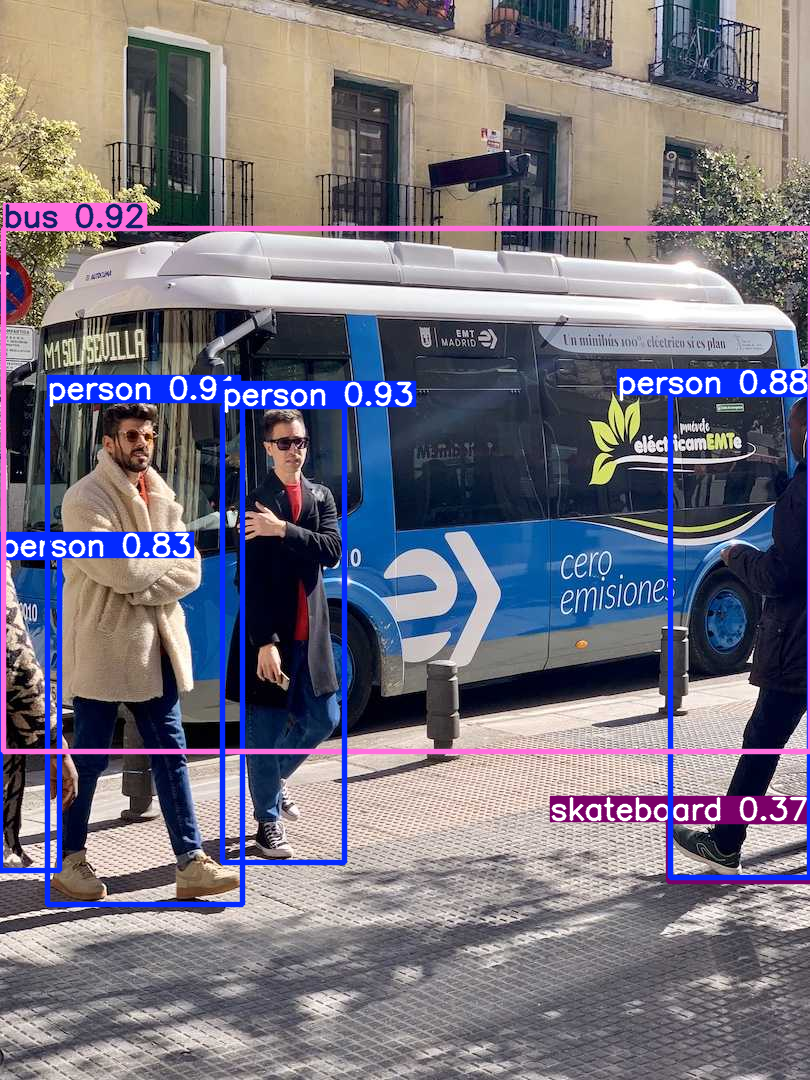

In [19]:
pred[0].show()

In [20]:
r = pred[0]

print("Boxes:", r.boxes.xyxy)
print("Confidence:", r.boxes.conf)
print("Classes:", r.boxes.cls)

Boxes: tensor([[222.2496, 406.1774, 344.4798, 862.7926],
        [  3.3898, 228.0380, 810.0000, 751.8075],
        [ 47.4109, 400.6935, 242.1761, 904.3858],
        [670.8165, 394.0142, 809.8597, 877.0531],
        [  0.0000, 557.6295,  59.8397, 870.7503],
        [668.1108, 821.6488, 810.0000, 881.1442]], device='cuda:0')
Confidence: tensor([0.9257, 0.9220, 0.9127, 0.8805, 0.8281, 0.3719], device='cuda:0')
Classes: tensor([ 0.,  5.,  0.,  0.,  0., 36.], device='cuda:0')


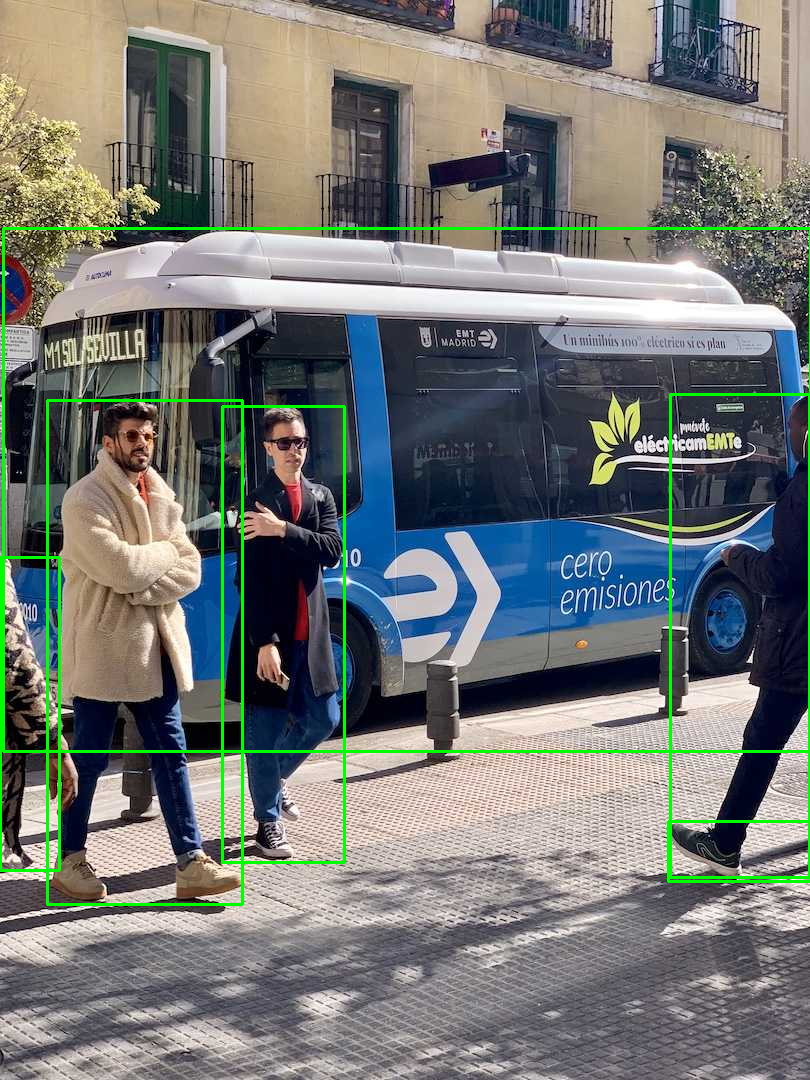

In [22]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/bus.jpg")

boxes = r.boxes.xyxy.cpu().numpy()

for box in boxes:
    x1,y1,x2,y2 = map(int, box)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

cv2_imshow(img)